In [1]:
import numpy as np
import networkx as nx


%load_ext autoreload
%autoreload 2

In [2]:
graphs_er = np.load("../Tutorials/ER/resolution-1/graphs-1_p-0.4.npy", allow_pickle=True)
graphs_er = [g[0] for g in graphs_er]
graphs_er_110_160 = np.load("graphs/erdos-renyi_110-160/erdos-renyi_110-160.npy", allow_pickle=True)
g_er_169 = np.load("graphs/erdos-renyi_110-160/erdos-renyi_169.npy", allow_pickle=True)
graphs_er = graphs_er + graphs_er_110_160.tolist() + g_er_169.tolist()

graphs_pwl = np.load("../Tutorials/Power-law/resolution-1/graphs-1_m-1_p-0.1.npy", allow_pickle=True)
graphs_pwl = [g[0] for g in graphs_pwl]
graphs_pwl_110_160 = np.load("graphs/powerlaw_110-160/powerlaw_graphs_110-160.npy", allow_pickle=True)
g_pwl_169 = np.load("graphs/powerlaw_110-160/powerlaw_graph_169.npy", allow_pickle=True)
graphs_pwl = graphs_pwl + graphs_pwl_110_160.tolist() + g_pwl_169.tolist()

In [3]:
results_dir_er = f"ER/resolution-1/graphs-1_p-0.4"
results_dir_pwl = f"Power-law/resolution-1/graphs-1_m-1_p-0.1"

In [4]:
from iterative_utils import IterativeSearchGraphResults
from Qommunity.searchers.utils import HierarchicalRunMetadata
import numpy as np

graphs_results_er = {}

num_runs = 20
graphs_sizes = [int(g.number_of_nodes()) for g in graphs_er]  # 10-160 + 169

for g_size in graphs_sizes:
    hierarchical_metadatas = []
    path = results_dir_er + f"/graph_size={g_size}"

    for iter in range(num_runs):
        base_filename = f"{path}/er_p=0.4_iter_{iter}"
        hm = HierarchicalRunMetadata.load_from_files(base_filename)
        hierarchical_metadatas.append(hm)

    if g_size == 169:
        # runs-5-extra
        path_5 = f"{results_dir_er}/runs-5-extra/erdos-renyi_169/graph_size=169"
        for iter in range(5):
            base_filename = f"{path_5}/er_p=0.4_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)
        
        # runs-20
        path_20 = f"{results_dir_er}/runs-20/erdos-renyi_169/graph_size=169"
        for iter in range(20):
            base_filename = f"{path_20}/er_p=0.4_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        # runs-20-extra
        path_20_extra = f"{results_dir_er}/runs-20-extra/erdos-renyi_169/graph_size=169"
        for iter in range(20):
            base_filename = f"{path_20_extra}/er_p=0.4_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        # runs-55-extra
        path_55_extra = f"{results_dir_er}/runs-55-extra/erdos-renyi_169/graph_size=169"
        for iter in range(55):
            base_filename = f"{path_55_extra}/er_p=0.4_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        communities_list = []
        modularities_list = []
        times_list = []
        div_mods_list = []
        div_trees_list = []

        for p in [path_5, path_20, path_20_extra, path_55_extra]:
            communities_list.append(np.load(f"{p}/er_p=0.4_communities.npy", allow_pickle=True))
            modularities_list.append(np.load(f"{p}/er_p=0.4_modularities.npy", allow_pickle=True))
            times_list.append(np.load(f"{p}/er_p=0.4_times.npy", allow_pickle=True))
            div_mods_list.append(np.load(f"{p}/er_p=0.4_division_modularities.npy", allow_pickle=True))
            div_trees_list.append(np.load(f"{p}/er_p=0.4_division_trees.npy", allow_pickle=True))

        communities = np.concatenate(communities_list, axis=0)
        modularities = np.concatenate(modularities_list, axis=0)
        times = np.concatenate(times_list, axis=0)
        division_modularities = np.concatenate(div_mods_list, axis=0)
        division_trees = np.concatenate(div_trees_list, axis=0)

    else:
        communities = np.load(f"{path}/er_p=0.4_communities.npy", allow_pickle=True)
        modularities = np.load(f"{path}/er_p=0.4_modularities.npy", allow_pickle=True)
        times = np.load(f"{path}/er_p=0.4_times.npy", allow_pickle=True)
        division_modularities = np.load(f"{path}/er_p=0.4_division_modularities.npy", allow_pickle=True)
        division_trees = np.load(f"{path}/er_p=0.4_division_trees.npy", allow_pickle=True)
    
    iterative_graph_results = IterativeSearchGraphResults(
        graph_ref=graphs_er[graphs_sizes.index(g_size)],
        graph_size=g_size,
        communities=communities,
        modularities=modularities,
        times=times,
        division_modularities=division_modularities,
        division_trees=division_trees,
        hierarchical_metadatas=hierarchical_metadatas
    )

    graphs_results_er[g_size] = iterative_graph_results

In [5]:
from Qommunity.searchers.utils import HierarchicalRunMetadata

graphs_results_pwl = {}

num_runs = 20
graph_sizes = [int(g.number_of_nodes()) for g in graphs_er] # 10-160 + 169
base = f"./{results_dir_pwl}"


for g_size in graph_sizes:
    path = base + f"/graph_size={g_size}/"
    communities = np.load(f"{path}/powerlaw_m=1_p=0.1_communities.npy", allow_pickle=True)
    modularities = np.load(f"{path}/powerlaw_m=1_p=0.1_modularities.npy", allow_pickle=True)
    times = np.load(f"{path}/powerlaw_m=1_p=0.1_times.npy", allow_pickle=True)
    division_modularities = np.load(f"{path}/powerlaw_m=1_p=0.1_division_modularities.npy", allow_pickle=True)
    division_trees = np.load(f"{path}/powerlaw_m=1_p=0.1_division_trees.npy", allow_pickle=True)

    graphs_results_path_base =  base + f"/graph_size={g_size}/powerlaw_m=1_p=0.1"
    hierarchical_metadatas = []
    
    if g_size == 150:
        for iter in range(16):
            base_filename = f"{graphs_results_path_base}_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)
        
        path = base + f"/graph_size={g_size}"
        for iter in range(3):
            base_filename = f"{path}-4runs/"+"powerlaw_m=1_p=0.1"+f"_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        for iter in range(3):
            base_filename = f"{path}-ex4runs/"+"powerlaw_m=1_p=0.1"+f"_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        for iter in range(21, 24, 1):
            base_filename = f"{path}-3runs/"+"powerlaw_m=1_p=0.1"+f"_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        comms_3 = np.load(f"{path}-ex4runs/powerlaw_m=1_p=0.1_communities.npy", allow_pickle=True)
        mods_3 = np.load(f"{path}-ex4runs/powerlaw_m=1_p=0.1_modularities.npy", allow_pickle=True)
        times_3 = np.load(f"{path}-ex4runs/powerlaw_m=1_p=0.1_times.npy", allow_pickle=True)
        div_mods_3 = np.load(f"{path}-ex4runs/powerlaw_m=1_p=0.1_division_modularities.npy", allow_pickle=True)
        div_trees_3 = np.load(f"{path}-ex4runs/powerlaw_m=1_p=0.1_division_trees.npy", allow_pickle=True)

        communities = communities[:-4]
        modularities = modularities[:-4]
        times = times[:-4]
        division_modularities = division_modularities[:-4]
        division_trees = division_trees[:-4]

        communities = np.concatenate((communities, comms_3), axis=0)
        modularities = np.concatenate((modularities, mods_3), axis=0)
        times = np.concatenate((times, times_3), axis=0)
        division_modularities = np.concatenate((division_modularities, div_mods_3), axis=0)
        division_trees = np.concatenate((division_trees, div_trees_3), axis=0)

    elif g_size == 169:
        # -----------------------------
        # 169-extra-20runs
        # -----------------------------
        path_20 = path = base + f"/graph_size={g_size}-extra-20runs"
        for iter in range(20):
            base_filename = f"{path_20}/powerlaw_m=1_p=0.1_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        comms_20 = np.load(f"{path_20}/powerlaw_m=1_p=0.1_communities.npy", allow_pickle=True)
        mods_20 = np.load(f"{path_20}/powerlaw_m=1_p=0.1_modularities.npy", allow_pickle=True)
        times_20 = np.load(f"{path_20}/powerlaw_m=1_p=0.1_times.npy", allow_pickle=True)
        div_mods_20 = np.load(f"{path_20}/powerlaw_m=1_p=0.1_division_modularities.npy", allow_pickle=True)
        div_trees_20 = np.load(f"{path_20}/powerlaw_m=1_p=0.1_division_trees.npy", allow_pickle=True)

        # -----------------------------
        # 169-extra-30runs
        # -----------------------------
        path_30 = path = base + f"/graph_size={g_size}-extra-30runs"
        for iter in range(30):
            base_filename = f"{path_30}/powerlaw_m=1_p=0.1_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)

        comms_30 = np.load(f"{path_30}/powerlaw_m=1_p=0.1_communities.npy", allow_pickle=True)
        mods_30 = np.load(f"{path_30}/powerlaw_m=1_p=0.1_modularities.npy", allow_pickle=True)
        times_30 = np.load(f"{path_30}/powerlaw_m=1_p=0.1_times.npy", allow_pickle=True)
        div_mods_30 = np.load(f"{path_30}/powerlaw_m=1_p=0.1_division_modularities.npy", allow_pickle=True)
        div_trees_30 = np.load(f"{path_30}/powerlaw_m=1_p=0.1_division_trees.npy", allow_pickle=True)

        communities = np.concatenate((comms_20, comms_30), axis=0)
        modularities = np.concatenate((mods_20, mods_30), axis=0)
        times = np.concatenate((times_20, times_30), axis=0)
        division_modularities = np.concatenate((div_mods_20, div_mods_30), axis=0)
        division_trees = np.concatenate((div_trees_20, div_trees_30), axis=0)
    else:
        for iter in range(num_runs):
            base_filename = f"{graphs_results_path_base}_iter_{iter}"
            hm = HierarchicalRunMetadata.load_from_files(base_filename)
            hierarchical_metadatas.append(hm)
    
    iterative_graph_results = IterativeSearchGraphResults(
        graph_ref = graphs_pwl[graph_sizes.index(g_size)],
        graph_size=g_size,
        communities = communities,
        modularities = modularities,
        times = times,
        division_modularities = division_modularities,
        division_trees = division_trees,
        hierarchical_metadatas=hierarchical_metadatas
    )

    graphs_results_pwl[g_size] = iterative_graph_results

In [6]:
# CHAIN STRENGTH
chain_strength_size_er = {}
for i in graphs_sizes:
    Nruns = len(graphs_results_er[i].hierarchical_metadatas)
    chain_strength = np.zeros((Nruns))
    for j in range(Nruns):
        Nsplits = len(graphs_results_er[i].hierarchical_metadatas[j])
        tmp = np.zeros((Nsplits))
        cbf_s = graphs_results_er[i].hierarchical_metadatas[j].chain_strength
        for k, cbf in enumerate(cbf_s):
        #for k in range(Nsplits):
        #    tmp[k] = graphs_results_er[i].hierarchical_metadatas[j][k].chain_strength
            tmp[k] = np.nan if cbf is None else cbf
        chain_strength[j] = np.nanmax(tmp)
    chain_strength_size_er[i] = chain_strength


chain_strength_size_pwl = {}
for i in graphs_sizes:
    Nruns = len(graphs_results_pwl[i].hierarchical_metadatas)
    chain_strength = np.zeros((Nruns))
    for j in range(Nruns):
        Nsplits = len(graphs_results_pwl[i].hierarchical_metadatas[j])
        tmp = np.zeros((Nsplits))
        cbf_s = graphs_results_pwl[i].hierarchical_metadatas[j].chain_strength
        for k, cbf in enumerate(cbf_s):
        #for k in range(Nsplits):
        #    tmp[k] = graphs_results_pwl[i].hierarchical_metadatas[j][k].chain_strength
            tmp[k] = np.nan if cbf is None else cbf
        chain_strength[j] = np.nanmax(tmp)
    chain_strength_size_pwl[i] = chain_strength

chain_strength_per_graph_size_er = np.array([chain_strength_size_er[g_size].max() for g_size in graph_sizes])
chain_strength_per_graph_size_pwl = np.array([chain_strength_size_pwl[g_size].max() for g_size in graph_sizes])

# CHAIN BREAK PROBABILITY
cbfs_maxes_per_graph_size_er = [graphs_results_er[g_size].cbfs_maxes for g_size in graph_sizes]
cbfs_maxes_per_graph_size_pwl = [graphs_results_pwl[g_size].cbfs_maxes for g_size in graph_sizes]

In [7]:
from scipy.stats import linregress

slope_er, intercept_er, r_er, p_er, se_er = linregress(np.log(graph_sizes), np.log(chain_strength_per_graph_size_er))
slope_pwl, intercept_pwl, r_pwl, p_pwl, se_pwl = linregress(np.log(graph_sizes), np.log(chain_strength_per_graph_size_pwl))

ps_er = "<0.001" if p_er<0.001 else "="+str(p_er.round(5))
ps_pwl = "<0.001" if p_pwl<0.001 else "="+str(p_pwl.round(5))

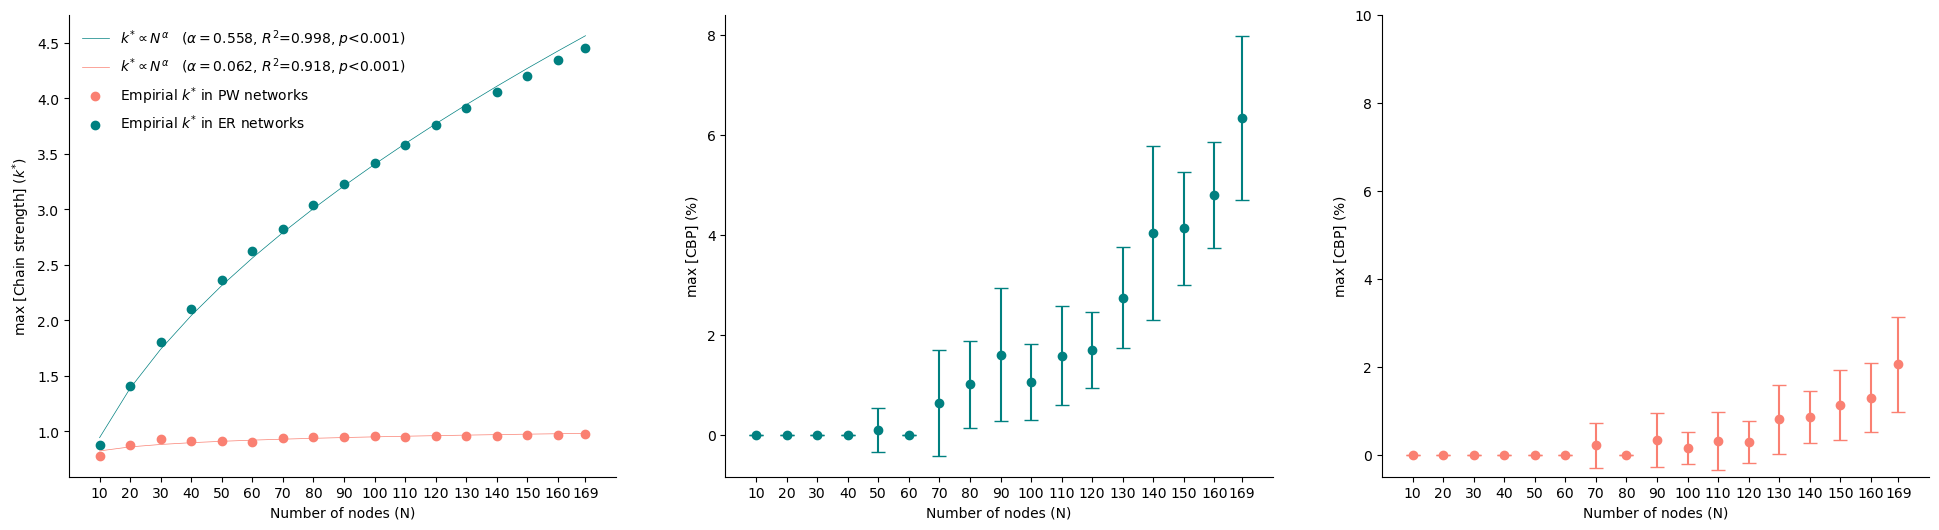

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import special

fig, ax = plt.subplots(1, 3, figsize=(24,6))

ax[0].plot(graph_sizes, np.exp(intercept_er)*(np.array(graph_sizes)**slope_er), color="teal", linewidth=.5, label=r'$k^{*} \propto N^{\alpha} \quad (\alpha=$'+f"{slope_er.round(3)}, "+r'$R^{2}$' + f"={r_er.round(3)}, "+r'$p$'+f"{ps_er})")
ax[0].plot(graph_sizes, np.exp(intercept_pwl)*(np.array(graph_sizes)**slope_pwl), color="salmon", linewidth=.5, label=r'$k^{*} \propto N^{\alpha} \quad (\alpha=$'+f"{slope_pwl.round(3)}, "+r'$R^{2}$' + f"={r_pwl.round(3)}, "+r'$p$'+f"{ps_pwl})")
ax[0].scatter(graph_sizes, chain_strength_per_graph_size_pwl, color="salmon", label="Empirial "+r'$k^{*}$'+" in PW networks")
ax[0].scatter(graph_sizes, chain_strength_per_graph_size_er, color="teal", label="Empirial "+r'$k^{*}$'+" in ER networks")

ax[0].set_xlabel("Number of nodes (N)")
ax[0].set_ylabel(r'$\max $'+" [Chain strength] "+r'$ (k^{*})$')

ax[0].set_xlim([0, graph_sizes[-1]+10])
ax[0].set_xticks(graph_sizes)
ax[0].set_xticklabels(graph_sizes)
ax[0].spines[["top","right"]].set_visible(False)
ax[0].legend(frameon=False)

ax[1].errorbar(graph_sizes, [np.mean(cbfs_maxes_per_graph_size_er[i])*100 for i in range(len(graph_sizes))], np.array([100*np.std(cbfs_maxes_per_graph_size_er[i]) for i in range(len(graph_sizes))]), fmt="o", color="teal", capsize=5)
#ax[1].plot(graph_sizes, special.erfc(chain_strength_per_graph_size_er/np.sqrt(np.array(graph_sizes))), color="black", linewidth=0.5)

ax[1].set_xlabel("Number of nodes (N)")
ax[1].set_ylabel(r'$\max $'+" [CBP] (%)")

ax[1].set_xlim([0, graph_sizes[-1]+10])
ax[1].set_xticks(graph_sizes)
ax[1].set_xticklabels(graph_sizes)
#ax[1].set_ylim([-.5,10])
ax[1].spines[["top","right"]].set_visible(False)

ax[2].errorbar(graph_sizes, [np.mean(cbfs_maxes_per_graph_size_pwl[i])*100 for i in range(len(graph_sizes))], np.array([100*np.std(cbfs_maxes_per_graph_size_pwl[i]) for i in range(len(graph_sizes))]), fmt="o", color="salmon", capsize=5)
#ax[1].plot(graph_sizes, special.erfc(chain_strength_per_graph_size_er/np.sqrt(np.array(graph_sizes))), color="black", linewidth=0.5)

ax[2].set_xlabel("Number of nodes (N)")
ax[2].set_ylabel(r'$\max $'+" [CBP] (%)")

ax[2].set_xlim([0, graph_sizes[-1]+10])
ax[2].set_xticks(graph_sizes)
ax[2].set_xticklabels(graph_sizes)
ax[2].set_ylim([-.5,10])
ax[2].spines[["top","right"]].set_visible(False)

fig.savefig("./Chain-strength_and_CBFs.svg", dpi=300, format="svg")

/var/folders/1d/yjz9s57x4pd3t5v7zyt1shp40000gn/T/ipykernel_59372/889000720.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(X,Y)
/var/folders/1d/yjz9s57x4pd3t5v7zyt1shp40000gn/T/ipykernel_59372/889000720.py:26: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(X,Y)
/var/folders/1d/yjz9s57x4pd3t5v7zyt1shp40000gn/T/ipykernel_59372/889000720.py:44: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(X,Y)
/var/folders/1d/yjz9s57x4pd3t5v7zyt1shp40000gn/T/ipykernel_59372/889000720.py:47: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(X,Y)


rho = -0.5445195814863617 p = 8.524185725960076e-34
rho = -0.25220543752250674 p = 3.162442306014309e-05
rho = -0.5998323858434541 p = 1.5879935032585811e-37
rho = -0.3595142131594593 p = 2.299218250781119e-05


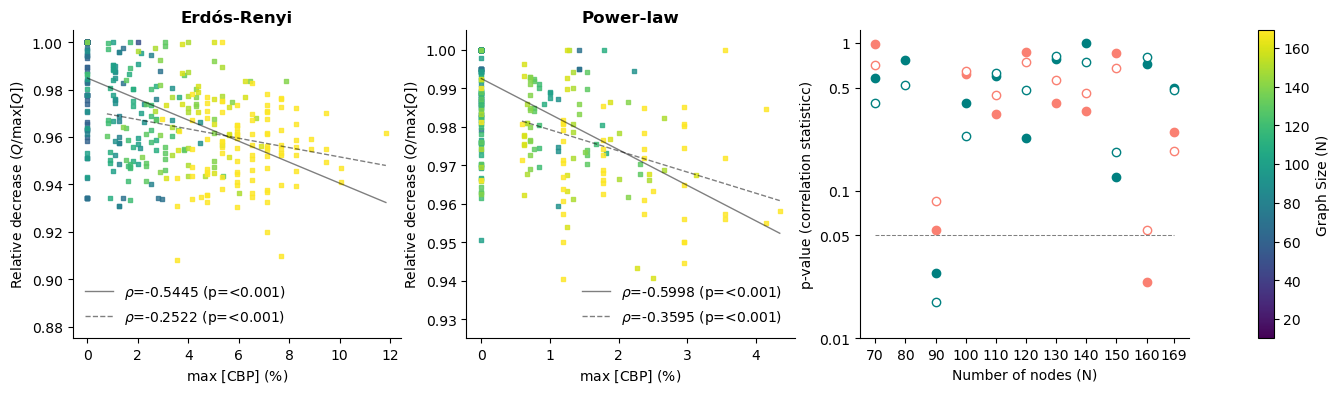

In [10]:
modularities_er = [graphs_results_er[i].modularities for i in graph_sizes]
modularities_pwl = [graphs_results_pwl[i].modularities for i in graph_sizes]

from scipy.stats import pearsonr, spearmanr
from matplotlib.colors import Normalize

cmap = plt.cm.viridis
norm = Normalize(vmin=min(graph_sizes), vmax=max(graph_sizes))
colors = cmap(np.linspace(0,1,len(graph_sizes)))

fig, ax = plt.subplots(1,3,figsize=(18,4))
x_er, y_er = [], []
x_pwl, y_pwl = [], []
rhos_er, rhos_pwl = [], []
rhos_ps_er, rhos_ps_pwl = [], []
spear_er, spear_pwl = [], []
spear_ps_er, spear_ps_pwl = [], []

for i, g in enumerate(graph_sizes):
    X = cbfs_maxes_per_graph_size_er[i][:100] if g==169 else cbfs_maxes_per_graph_size_er[i]
    Y = modularities_er[i] / max(modularities_er[i])

    r, p = pearsonr(X,Y)
    rhos_er.append(r)
    rhos_ps_er.append(p)
    r, p = spearmanr(X,Y)
    spear_er.append(r)
    spear_ps_er.append(p)

    x_er.extend(X)
    y_er.extend(Y)
    ax[0].scatter(
        100*np.array(X),
        np.array(Y),
        marker="s",
        color=colors[i],
        alpha=0.8,
        s=10
    )

    X = cbfs_maxes_per_graph_size_pwl[i][:20] if g==150 else cbfs_maxes_per_graph_size_pwl[i]
    Y = modularities_pwl[i] / max(modularities_pwl[i])

    r, p = pearsonr(X,Y)
    rhos_pwl.append(r)
    rhos_ps_pwl.append(p)
    r, p = spearmanr(X,Y)
    spear_pwl.append(r)
    spear_ps_pwl.append(p)

    x_pwl.extend(X)
    y_pwl.extend(Y)
    ax[1].scatter(
        100*np.array(X),
        np.array(Y),
        marker="s",
        color=colors[i],
        alpha=0.8,
        s=10
    )

ax[0].spines[["top", "right"]].set_visible(False)
ax[0].set_ylim([0.875, 1.005])
ax[0].set_xlabel(r'$\max $'+" [CBP] (%)")
ax[0].set_title("Erdós-Renyi", fontweight="bold")

ax[1].spines[["top", "right"]].set_visible(False)
ax[1].set_ylim([0.925, 1.005])
ax[1].set_xlabel(r'$\max $'+" [CBP] (%)")
ax[1].set_title("Power-law", fontweight="bold")

x_er, y_er = np.array(x_er), np.array(y_er)
r_er, p_er = pearsonr(x_er,y_er)
r_er_0, p_er_0 = pearsonr(x_er[x_er!=0],y_er[x_er!=0])

slope, intercept, r, p, stderr = linregress(100*x_er, y_er)
xfit = 100*np.linspace(x_er.min(), x_er.max(), 200)
yfit = intercept + slope*xfit
ax[0].plot(xfit, yfit, color="black", linewidth=1, label=r'$\rho$'+f"={r_er.round(4)} (p={"<0.001" if p_er<0.001 else p_er.round(4)})", alpha=0.5)

slope, intercept, r, p, stderr = linregress(100*x_er[x_er!=0], y_er[x_er!=0])
xfit = 100*np.linspace(x_er[x_er!=0].min(), x_er.max(), 200)
yfit = intercept + slope*xfit
ax[0].plot(xfit, yfit, color="black", linewidth=1, label=r'$\rho$'+f"={r_er_0.round(4)} (p={"<0.001" if p_er_0<0.001 else p_er_0.round(4)})", alpha=0.5, linestyle="--")
ax[0].set_ylabel("Relative decrease "+r'$(Q/\max[Q])$')
ax[0].legend(frameon=False)

x_pwl, y_pwl = np.array(x_pwl), np.array(y_pwl)
r_pwl, p_pwl = pearsonr(x_pwl,y_pwl)
r_pwl_0, p_pwl_0 = pearsonr(x_pwl[x_pwl!=0],y_pwl[x_pwl!=0])

slope, intercept, r, p, stderr = linregress(100*x_pwl, y_pwl)
xfit = 100*np.linspace(x_pwl.min(), x_pwl.max(), 200)
yfit = intercept + slope*xfit
ax[1].plot(xfit, yfit, color="black", linewidth=1, label=r'$\rho$'+f"={r_pwl.round(4)} (p={"<0.001" if p_pwl<0.001 else p_pwl.round(4)})", alpha=0.5)

slope, intercept, r, p, stderr = linregress(100*x_pwl[x_pwl!=0], y_pwl[x_pwl!=0])
xfit = 100*np.linspace(x_pwl[x_pwl!=0].min(), x_pwl.max(), 200)
yfit = intercept + slope*xfit
ax[1].plot(xfit, yfit, color="black", linewidth=1, label=r'$\rho$'+f"={r_pwl_0.round(4)} (p={"<0.001" if p_pwl_0<0.001 else p_pwl_0.round(4)})", alpha=0.5, linestyle="--")
ax[1].set_ylabel("Relative decrease "+r'$(Q/\max[Q])$')
ax[1].legend(frameon=False)

# ---- Colorbar instead of legend ----
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, label="Graph Size (N)")

print("rho =",r_er, "p =",p_er)
print("rho =",r_er_0, "p =",p_er_0) 
print("rho =",r_pwl, "p =",p_pwl)
print("rho =",r_pwl_0, "p =",p_pwl_0)

ax[2].scatter(graph_sizes, np.log(rhos_ps_er), facecolor="teal", edgecolor="teal", label="Pearson in ER networks")
ax[2].scatter(graph_sizes, np.log(spear_ps_er), facecolor="white", edgecolor="teal", label="Spearman in ER networks")
ax[2].scatter(graph_sizes, np.log(rhos_ps_pwl), facecolor="salmon", edgecolor="salmon", label="Pearson in PW networks")
ax[2].scatter(graph_sizes, np.log(spear_ps_pwl), facecolor="white", edgecolor="salmon", label="Spearman in PW networks")
ax[2].hlines(np.log(0.05), graph_sizes[-11], graph_sizes[-1], linestyle="--", color="gray", linewidth=0.75)
ax[2].set_xticks(graph_sizes[-11:])
ax[2].set_xlabel("Number of nodes (N)")
ax[2].set_yticks(np.log([0.01,0.05,0.1,0.5,1]))
ax[2].set_yticklabels([0.01,0.05,0.1,0.5,1])
ax[2].spines[["top", "right"]].set_visible(False)
ax[2].set_ylabel("p-value (correlation statisticc)")

fig.savefig("./CBFs_and_modularity.svg", dpi=300, format="svg")

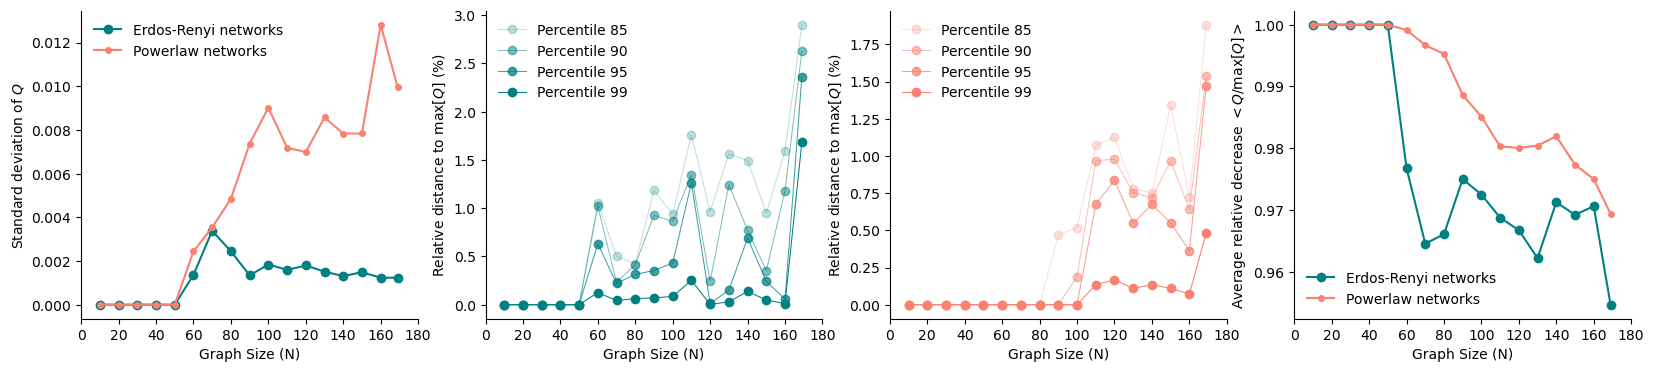

In [11]:
fig, ax = plt.subplots(1,4,figsize=(20,4))

ax[0].plot(graph_sizes, [np.std(modularities_er[i]) for i in range(len(graph_sizes))], "-o", color="teal", label="Erdos-Renyi networks")
ax[0].plot(graph_sizes, [np.std(modularities_pwl[i]) for i in range(len(graph_sizes))], "-o", color="salmon", label="Powerlaw networks", markersize=4)
ax[0].set_xticks(range(0,190,20))
ax[0].legend(frameon=False)
ax[0].spines[["top","right"]].set_visible(False)
ax[0].set_xlabel("Graph Size (N)")
ax[0].set_ylabel("Standard deviation of "+r'$Q$')

ax[1].plot(graph_sizes, [100*(1-np.percentile(modularities_er[i],85)/max(modularities_er[i])) for i in range(len(graph_sizes))], "-o", color="teal", alpha=0.25, linewidth=.75, label="Percentile 85")
ax[1].plot(graph_sizes, [100*(1-np.percentile(modularities_er[i],90)/max(modularities_er[i])) for i in range(len(graph_sizes))], "-o", color="teal", alpha=0.5, linewidth=.75, label="Percentile 90")
ax[1].plot(graph_sizes, [100*(1-np.percentile(modularities_er[i],95)/max(modularities_er[i])) for i in range(len(graph_sizes))], "-o", color="teal", alpha=0.75, linewidth=.75, label="Percentile 95")
ax[1].plot(graph_sizes, [100*(1-np.percentile(modularities_er[i],99)/max(modularities_er[i])) for i in range(len(graph_sizes))], "-o", color="teal", alpha=1, linewidth=.75, label="Percentile 99")
ax[1].legend(frameon=False)
ax[1].set_xticks(range(0,190,20))
ax[1].spines[["top","right"]].set_visible(False)
ax[1].set_xlabel("Graph Size (N)")
ax[1].set_ylabel("Relative distance to "+r'$\max[Q]$'+" (%)")

ax[2].plot(graph_sizes, [100*(1-np.percentile(modularities_pwl[i],85)/max(modularities_pwl[i])) for i in range(len(graph_sizes))], "-o", color="salmon", alpha=0.25, linewidth=.75, label="Percentile 85")
ax[2].plot(graph_sizes, [100*(1-np.percentile(modularities_pwl[i],90)/max(modularities_pwl[i])) for i in range(len(graph_sizes))], "-o", color="salmon", alpha=0.5, linewidth=.75, label="Percentile 90")
ax[2].plot(graph_sizes, [100*(1-np.percentile(modularities_pwl[i],95)/max(modularities_pwl[i])) for i in range(len(graph_sizes))], "-o", color="salmon", alpha=0.75, linewidth=.75, label="Percentile 95")
ax[2].plot(graph_sizes, [100*(1-np.percentile(modularities_pwl[i],99)/max(modularities_pwl[i])) for i in range(len(graph_sizes))], "-o", color="salmon", alpha=1, linewidth=.75, label="Percentile 99")
ax[2].legend(frameon=False)
ax[2].set_xticks(range(0,190,20))
ax[2].spines[["top","right"]].set_visible(False)
ax[2].set_xlabel("Graph Size (N)")
ax[2].set_ylabel("Relative distance to "+r'$\max[Q]$'+" (%)")

ax[3].plot(graph_sizes, [np.mean(modularities_er[i])/max(modularities_er[i]) for i in range(len(graph_sizes))], "-o", color="teal", label="Erdos-Renyi networks")
ax[3].plot(graph_sizes, [np.mean(modularities_pwl[i])/max(modularities_pwl[i]) for i in range(len(graph_sizes))], "-o", color="salmon", label="Powerlaw networks", markersize=4)
ax[3].set_xticks(range(0,190,20))
ax[3].legend(frameon=False)
ax[3].spines[["top","right"]].set_visible(False)
ax[3].set_xlabel("Graph Size (N)")
ax[3].set_ylabel("Average relative decrease "+r'$<Q/\max[Q]>$')

fig.savefig("./Noise_and_modularity.svg", dpi=300, format="svg")

In [ ]:
G = g_pwl_169[0] #nx.karate_club_graph() #g_er_169[0]

from Qommunity.samplers.hierarchical.advantage_sampler import AdvantageSampler
from Qommunity.iterative_searcher import IterativeSearcher
from joblib import Parallel, delayed

def evaluate_k(k):
    adv_sampler = AdvantageSampler(
        G,
        resolution=1,
        num_reads=100,
        use_clique_embedding=True,
        chain_strength=float(k.round(2))
    )
    adv_iterative = IterativeSearcher(adv_sampler)
    _, mod_all, _ = adv_iterative.run(num_runs=20, save_results=False)
    m = np.array([mod_all.mean(), mod_all.std(), k.round(2), mod_all.max()])
    np.save(f"./modularities_strength-{k.round(2)}_PWL-169_all-mods.npy", mod_all, allow_pickle=True)
    return m

# n_jobs=-1 uses all CPUs; adjust if needed
results = Parallel(n_jobs=4, verbose=10)(
    delayed(evaluate_k)(k) for k in [np.float32(0.8), np.float32(0.7), np.float32(0.9), np.float32(1.0)]#ks_to_try
)
mod_k = np.vstack(results)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
100%|██████████| 20/20 [7:44:36<00:00, 1393.81s/it]  
[Parallel(n_jobs=4)]: Done   1 tasks      | elapsed: 464.7min
100%|██████████| 20/20 [8:56:00<00:00, 1608.03s/it]  
[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed: 536.1min remaining: 536.1min
100%|██████████| 20/20 [8:56:32<00:00, 1609.63s/it]
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed: 536.6min finished


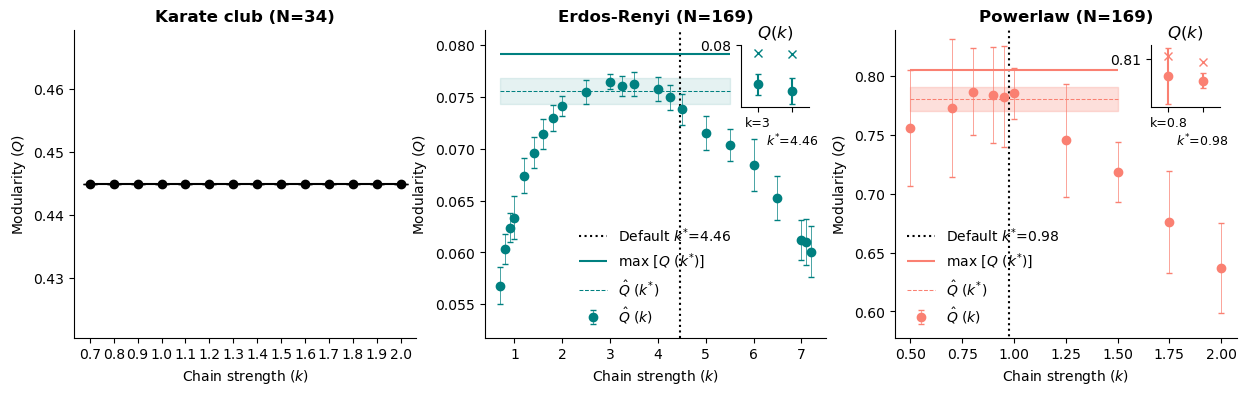

In [12]:
# Erdos-Renyi results
ms_er = np.load("./modularities_chain-strength_ER-169.npy", allow_pickle=True)
ms_er_all_optim = np.load("./modularities_strength-3.0_ER-169_all-mods.npy", allow_pickle=True)
ks_to_try_er = ms_er[:,2]
# Powerlaw results
ms_pwl = np.load("./modularities_chain-strength_PWL-169.npy", allow_pickle=True)
ms_pwl_all_optim = np.load("./modularities_chain-strength_PWL-169_all-mods.npy", allow_pickle=True)
ks_to_try_pwl = ms_pwl[:,2]
ms_pwl_all_optim = ms_pwl_all_optim[ks_to_try_pwl==ms_pwl[ms_pwl[:,0].argmax()][2]][0]
# Karate club results
ms_kar = np.load("./modularities_chain-strength_Karate.npy", allow_pickle=True)

## PLOTS
fig, ax = plt.subplots(1, 3, figsize=(15,4))

ax[0].errorbar(ms_kar[:,2], ms_kar[:,0], yerr=ms_kar[:,1], capsize=5, fmt="-o", color="black")
ax[0].set_xticks(ms_kar[:,2])
ax[0].set_xticklabels(ms_kar[:,2])
ax[0].spines[["top", "right"]].set_visible(False)
ax[0].set_xlabel("Chain strength "+r'$(k)$')
ax[0].set_ylabel("Modularity "+r'$(Q)$')
ax[0].set_title("Karate club (N=34)", fontweight="bold")

## Erdos-Renyi
ax[1].vlines(chain_strength_per_graph_size_er[-1], min(ms_er[:,0])-0.005, max(ms_er[:,0])+0.005, linestyle="dotted", color="black", label="Default "+r'$k^{*}$'+f"={chain_strength_per_graph_size_er[-1].round(2)}")
ax[1].errorbar(ms_er[:,2], ms_er[:,0], yerr=ms_er[:,1], capsize=2.5, fmt="o", color="teal", label=r'$\hat{Q} \ (k)$', linewidth=0.5)#, markersize=2)
ax[1].hlines(max(modularities_er[-1]), ms_er[0,2], 5.5, color="teal", label=r'$\max \ [Q \ (k^{*})]$')
ax[1].hlines(np.mean(modularities_er[-1]), ms_er[0,2], 5.5, color="teal", linestyle="--", linewidth=0.75, label=r'$\hat{Q} \ (k^{*})$')
ax[1].fill_between(
    [ms_er[0,2],5.5], 
    np.mean(modularities_er[-1])+np.std(modularities_er[-1]), 
    np.mean(modularities_er[-1])-np.std(modularities_er[-1]), 
    alpha=0.1, color="teal"
)
ax[1].set_ylim([min(ms_er[:,0])-0.005, max(ms_er[:,0])+0.005])
ax[1].spines[["top", "right"]].set_visible(False)
ax[1].set_xlabel("Chain strength "+r'$(k)$')
ax[1].set_ylabel("Modularity "+r'$(Q)$')
ax[1].legend(frameon=False)
ax[1].set_title("Erdos-Renyi (N=169)", fontweight="bold")

inset = ax[1].inset_axes([0.75,0.75,0.2,0.2])
inset.errorbar([0, 1], [np.mean(ms_er_all_optim), np.mean(modularities_er[-1])], fmt="o", yerr=[np.std(ms_er_all_optim),np.std(modularities_er[-1])], capsize=2.5, color="teal")
inset.plot([0, 1], [np.max(ms_er_all_optim), np.max(modularities_er[-1])], "x", markerfacecolor="white", color="teal")
inset.set_xlim([-.5,1.5])
inset.set_xticks([0,1])
inset.set_xticklabels([f"k=3", "\n"+r'$k^{*}$'+f"={chain_strength_per_graph_size_er[-1].round(2)}"], fontsize=9)
inset.set_yticks([np.max(modularities_er[-1]).round(2)])
inset.set_title(r'$Q(k)$')
inset.spines[["top","right"]].set_visible(False)

## Powerlaw
ax[2].vlines(chain_strength_per_graph_size_pwl[-1], min(ms_pwl[:,0])-0.1, max(ms_pwl[:,-1])+0.02, linestyle="dotted", color="black", label="Default "+r'$k^{*}$'+f"={chain_strength_per_graph_size_pwl[-1].round(2)}")
ax[2].errorbar(ms_pwl[:,2], ms_pwl[:,0], yerr=ms_pwl[:,1], capsize=2.5, fmt="o", color="salmon", label=r'$\hat{Q} \ (k)$', linewidth=0.5)#, markersize=2)
ax[2].hlines(max(modularities_pwl[-1]), ms_pwl[0,2], 1.5, color="salmon", label=r'$\max \ [Q \ (k^{*})]$')
ax[2].hlines(np.mean(modularities_pwl[-1]), ms_pwl[0,2], 1.5, color="salmon", linestyle="--", linewidth=0.75, label=r'$\hat{Q} \ (k^{*})$')
ax[2].fill_between(
    [ms_pwl[0,2],1.5], 
    np.mean(modularities_pwl[-1])+np.std(modularities_pwl[-1]), 
    np.mean(modularities_pwl[-1])-np.std(modularities_pwl[-1]), 
    alpha=0.25, color="salmon"
)
ax[2].set_ylim([min(ms_pwl[:,-1])-0.1, max(ms_pwl[:,-1])+0.02])
ax[2].spines[["top", "right"]].set_visible(False)
ax[2].set_xlabel("Chain strength "+r'$(k)$')
ax[2].set_ylabel("Modularity "+r'$(Q)$')
ax[2].legend(frameon=False)
ax[2].set_title("Powerlaw (N=169)", fontweight="bold")

inset = ax[2].inset_axes([0.75,0.75,0.2,0.2])
inset.errorbar([0, 1], [np.mean(ms_pwl_all_optim), np.mean(modularities_pwl[-1])], fmt="o", yerr=[np.std(ms_pwl_all_optim),np.std(modularities_pwl[-1])], capsize=2.5, color="salmon")
inset.plot([0, 1], [np.max(ms_pwl_all_optim), np.max(modularities_pwl[-1])], "x", markerfacecolor="white", color="salmon")
inset.set_xlim([-.5,1.5])
inset.set_xticks([0,1])
inset.set_xticklabels([f"k=0.8", "\n"+r'$k^{*}$'+f"={chain_strength_per_graph_size_pwl[-1].round(2)}"], fontsize=9)
inset.set_yticks([np.max(modularities_pwl[-1]).round(2)])
inset.set_title(r'$Q(k)$')
inset.spines[["top","right"]].set_visible(False)

fig.savefig("./Chain-strength_performance.svg", dpi=300, format="svg")